<a href="https://colab.research.google.com/github/elthonjakebasalo346-sys/elthon/blob/main/basalo_ml_activity_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [110]:
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


In [111]:
print(os.listdir(path))

['student-por.csv']


In [112]:
file_path=os.path.join(path,"student-por.csv")
df=pd.read_csv(file_path, sep=",")

In [113]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [114]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,4,10,11,11


In [115]:
print("Number of rowa: ", df.shape[0])
print ("Number of colums: ", df.shape[1])

Number of rowa:  649
Number of colums:  33


In [116]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [118]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [119]:
print("Average final grade", df["G3"].mean())

Average final grade 11.906009244992296


In [120]:
print("Minimum final grade: ", df["G3"].min())
print("Maximum final grade:", df["G3"].max())

Minimum final grade:  0
Maximum final grade: 19


In [121]:
print(df["sex"].value_counts())

sex
F    383
M    266
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

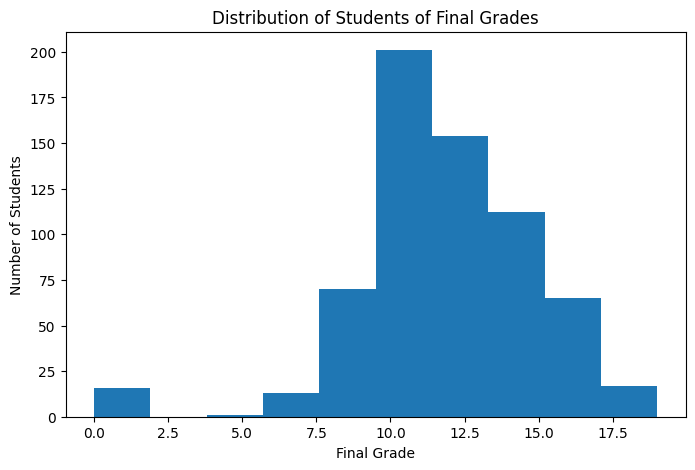

In [122]:
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Students of Final Grades")
plt.show()


In [123]:
df.groupby("sex")["G3"].mean()

,G3
sex,
F,12.253264
M,11.406015


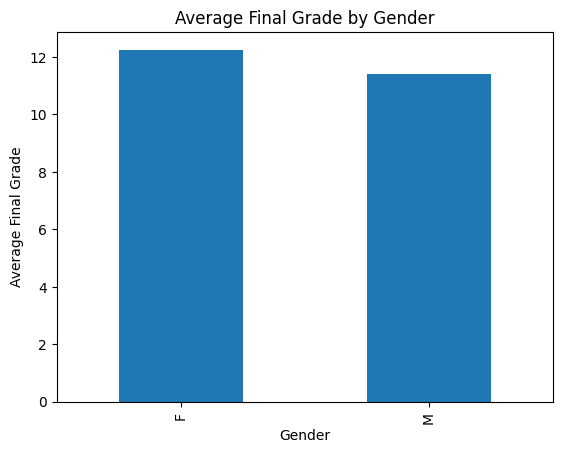

In [124]:
df.groupby("sex")["G3"].mean().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")
plt.show()

In [125]:
df.groupby("studytime")["G3"].mean()

,G3
studytime,
1,10.844340
2,12.091803
3,13.226804
4,13.057143


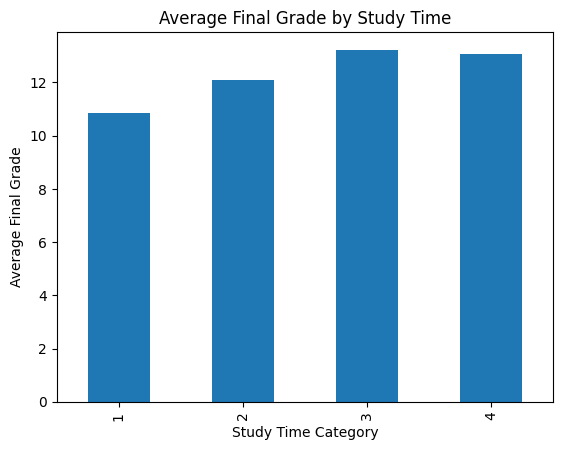

In [126]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")
plt.show()

Text(0.5, 1.0, 'Absences vs Final Grade')

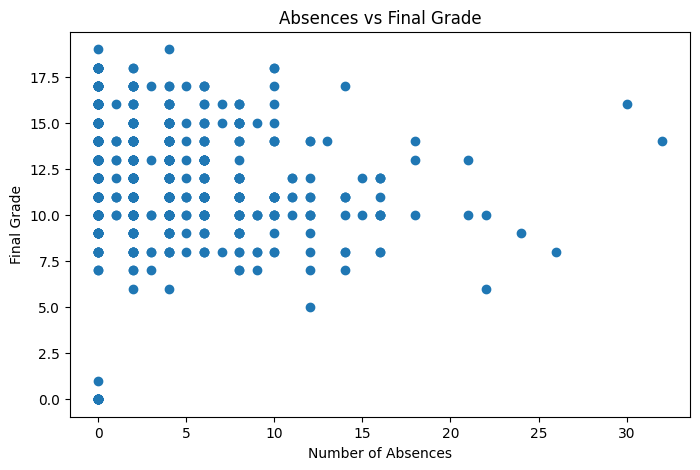

In [127]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

In [128]:
print(df["absences"].corr(df["G3"]))

-0.0913790564387561


In [129]:
df["pass"]= (df["G3"]>=10).astype(int)

In [130]:
print(df["pass"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      1
3      1
4      1
      ..
644    1
645    1
646    0
647    1
648    1
Name: pass, Length: 649, dtype: int64>


In [131]:
features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
]

x=df[features]
y=df["pass"]

In [132]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state = 42,
    stratify=y
)


In [133]:
model=DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [134]:
y_pred = model.predict(x_test)
print(y_pred)

[1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1
 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [135]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.8692307692307693


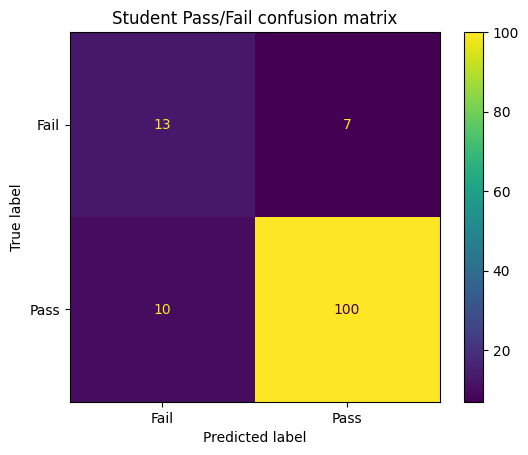

In [136]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
    )

disp.plot()
plt.title("Student Pass/Fail confusion matrix")
plt.show()

In [137]:
results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results.head(10)

,age,studytime,failures,absences,G1,Actual,Predicted
28,16,2,0,2,12,1,1
124,16,2,0,0,12,1,1
135,16,1,0,12,15,1,1
641,18,3,0,0,14,1,1
552,19,2,2,2,9,1,1
570,16,1,0,6,7,0,0
502,17,4,1,2,10,0,1
410,17,2,0,0,13,1,1
596,17,2,0,0,17,1,1
324,18,1,0,10,10,1,1


In [138]:
results["Risk"] = results["Predicted"].map({
    0: "At Risk",
    1: "Likely to Pass"
})

results.head(10)

,age,studytime,failures,absences,G1,Actual,Predicted,Risk
28,16,2,0,2,12,1,1,Likely to Pass
124,16,2,0,0,12,1,1,Likely to Pass
135,16,1,0,12,15,1,1,Likely to Pass
641,18,3,0,0,14,1,1,Likely to Pass
552,19,2,2,2,9,1,1,Likely to Pass
570,16,1,0,6,7,0,0,At Risk
502,17,4,1,2,10,0,1,Likely to Pass
410,17,2,0,0,13,1,1,Likely to Pass
596,17,2,0,0,17,1,1,Likely to Pass
324,18,1,0,10,10,1,1,Likely to Pass


In [141]:
probabilities = model.predict_proba(x_test)

results["Probability_of_Failing"] = probabilities[:,0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(10)

,age,studytime,failures,absences,G1,Actual,Predicted,Risk,Probability_of_Failing
175,17,2,2,4,7,0,0,At Risk,1.000000
487,18,3,2,6,7,1,0,At Risk,1.000000
567,18,1,1,0,4,0,0,At Risk,1.000000
500,17,1,1,12,6,0,0,At Risk,1.000000
557,17,2,3,2,7,1,0,At Risk,1.000000
408,18,2,0,11,9,1,0,At Risk,0.857143
254,18,2,1,16,9,1,0,At Risk,0.857143
624,17,1,1,0,8,0,0,At Risk,0.846154
255,18,1,1,14,8,0,0,At Risk,0.846154
578,17,2,1,4,8,1,0,At Risk,0.846154
